# About this Notebook

- **Data**: https://www.kaggle.com/datasets/waddahali/order-delivery-dataset

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"C:\Users\Rudra\Desktop\kaggle\order-delivery\talabat_enhanced_orders.csv"

In [3]:
df = pd.read_csv(path)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [5]:
df.head(2)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online


In [6]:
df.columns

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')

In [7]:
df = df.drop(columns=['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID'])

In [8]:
df = df.drop(columns=['Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon'])

In [9]:
df["Order_Time"] = pd.to_datetime(df["Order_Time"])

In [10]:
df["Delivery_Time"] = pd.to_datetime(df["Delivery_Time"])

- Now data is read for eda
- In this notebook we not perform Geo EDA

In [11]:
for col in df.columns:
    print(f"{col} {df[col].nunique()}")

Item_Name 9
Quantity 5
Total_Price 36321
Order_Time 21367
Delivery_Time 21396
Delivery_Duration_Minutes 46
City 7
Payment_Method 3
Order_Status 3
Driver_Vehicle 3
Delivery_Distance_km 100000
Traffic_Level 3
Driver_Availability 2


# Which Vehicle is so fast

Driver_Vehicle
Motorbike    37.481847
Bicycle      37.528344
Car          37.549997
Name: Delivery_Duration_Minutes, dtype: float64


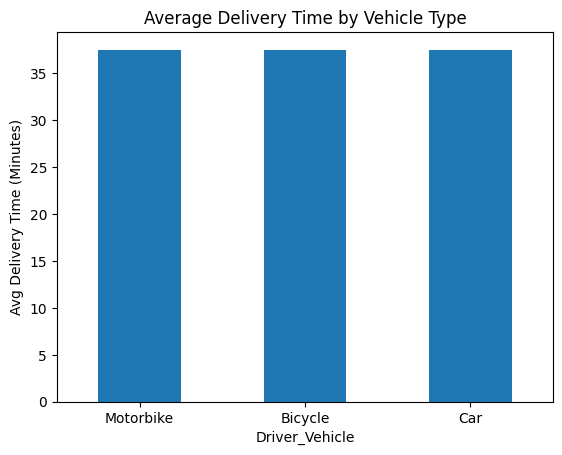

In [25]:
vehicle_speed = (
    df.groupby("Driver_Vehicle")["Delivery_Duration_Minutes"]
      .mean()
      .sort_values()
)

print(vehicle_speed)

plt.figure()
vehicle_speed.plot(kind="bar")
plt.title("Average Delivery Time by Vehicle Type")
plt.ylabel("Avg Delivery Time (Minutes)")
plt.xticks(rotation=0)
plt.show()

# Corr

In [ ]:
plt.scatter(df["Delivery_Distance_km"], df["Delivery_Duration_Minutes"])
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Duration (Minutes)")
plt.title("Distance vs Delivery Time")
plt.show()

<Axes: >

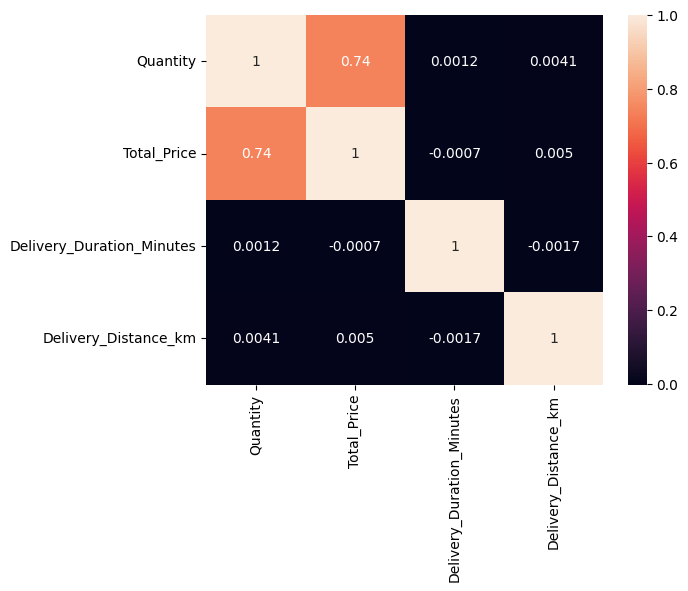

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Which city has highest average delivery time?

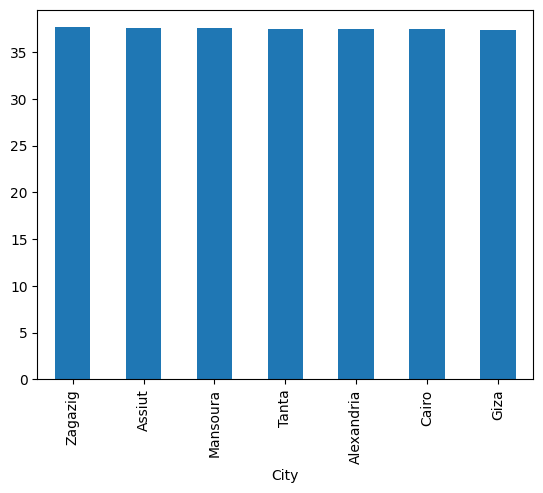

In [19]:
df.groupby("City")["Delivery_Duration_Minutes"].mean() \
    .sort_values(ascending=False).plot(kind="bar")

plt.show()

# All in One

In [12]:
draw_pie_col_list = ['Item_Name', 'Quantity', 'City', 'Payment_Method', 'Order_Status',
                  'Driver_Vehicle', 'Traffic_Level','Driver_Availability']

In [13]:
def plot_pie(col):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Delivery Duration
    duration_df = df.groupby(col)["Delivery_Duration_Minutes"].sum().reset_index()
    ax[0].pie(duration_df["Delivery_Duration_Minutes"], labels=duration_df[col], autopct="%2.1f%%")
    ax[0].set_title(f"Total Duration by {col}")

    # Total Price
    price_df = df.groupby(col)["Total_Price"].sum().reset_index()
    ax[1].pie(price_df["Total_Price"], labels=price_df[col], autopct="%2.1f%%")
    ax[1].set_title(f"Total Price by {col}")

    # Delivery Distance
    delivery_df = df.groupby(col)["Delivery_Distance_km"].sum().reset_index()
    ax[2].pie(delivery_df["Delivery_Distance_km"], labels=delivery_df[col], autopct="%2.1f%%")
    ax[2].set_title(f"Total Distance by {col}")

    plt.tight_layout()
    plt.show()


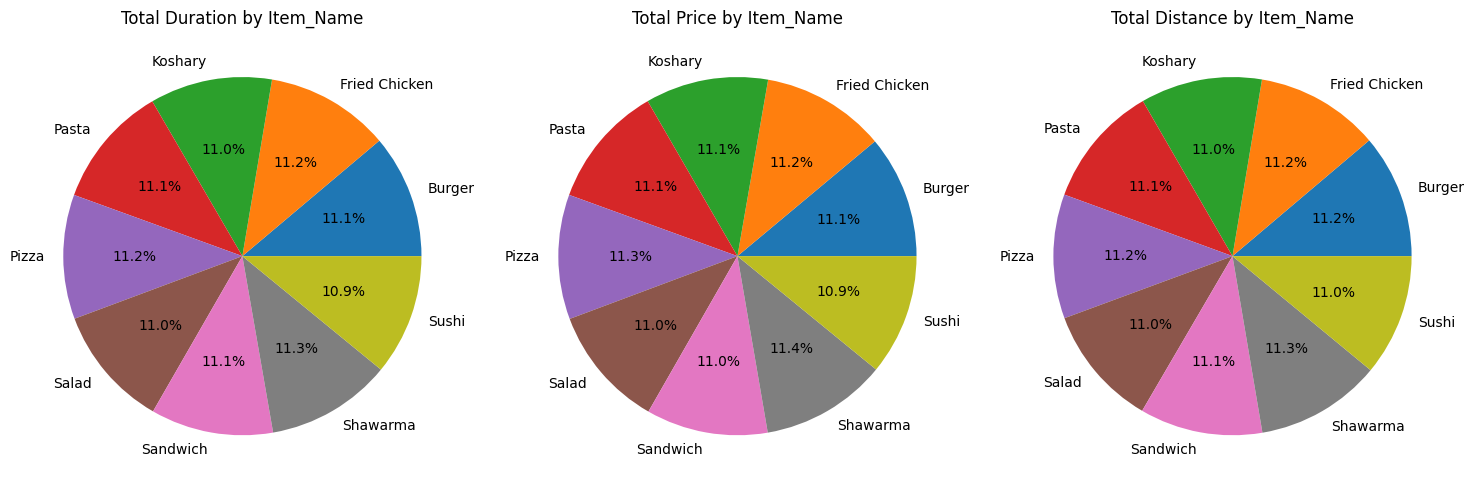

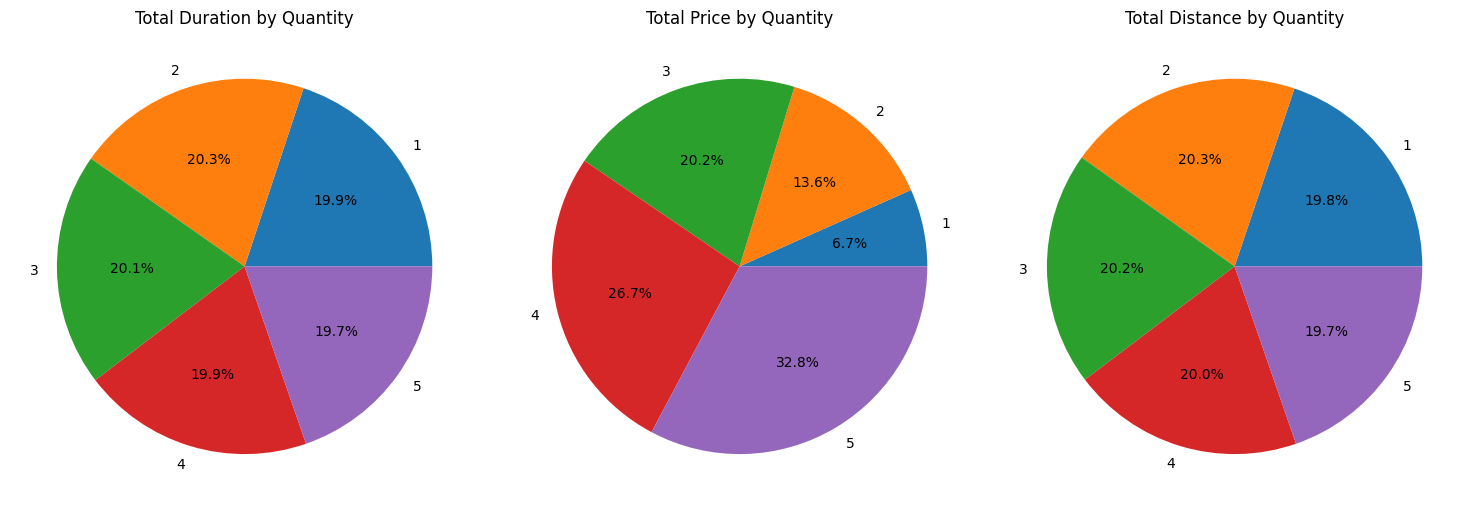

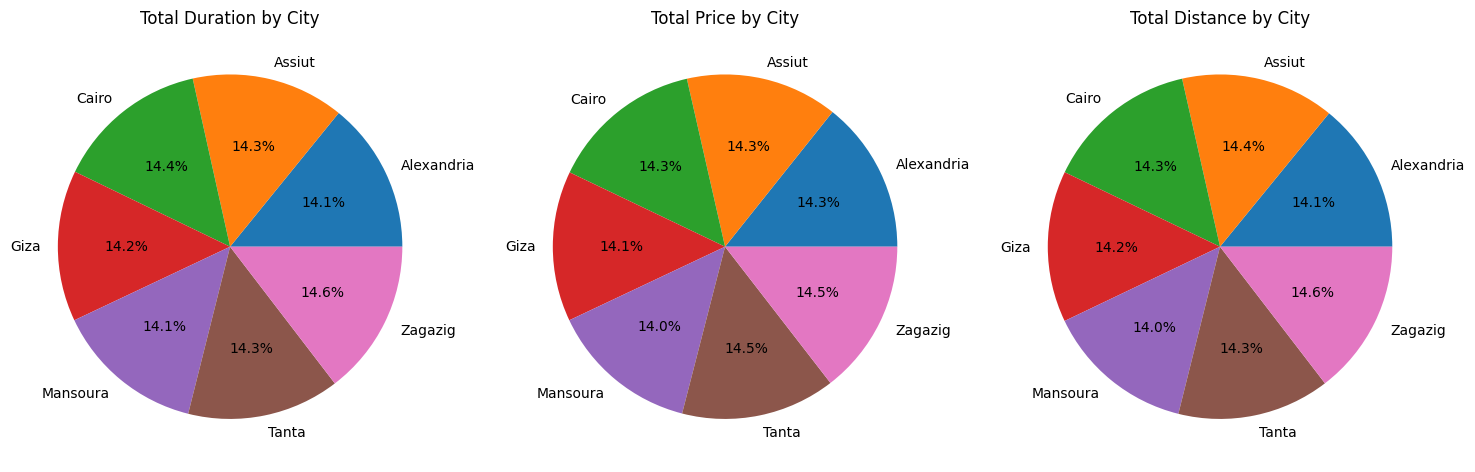

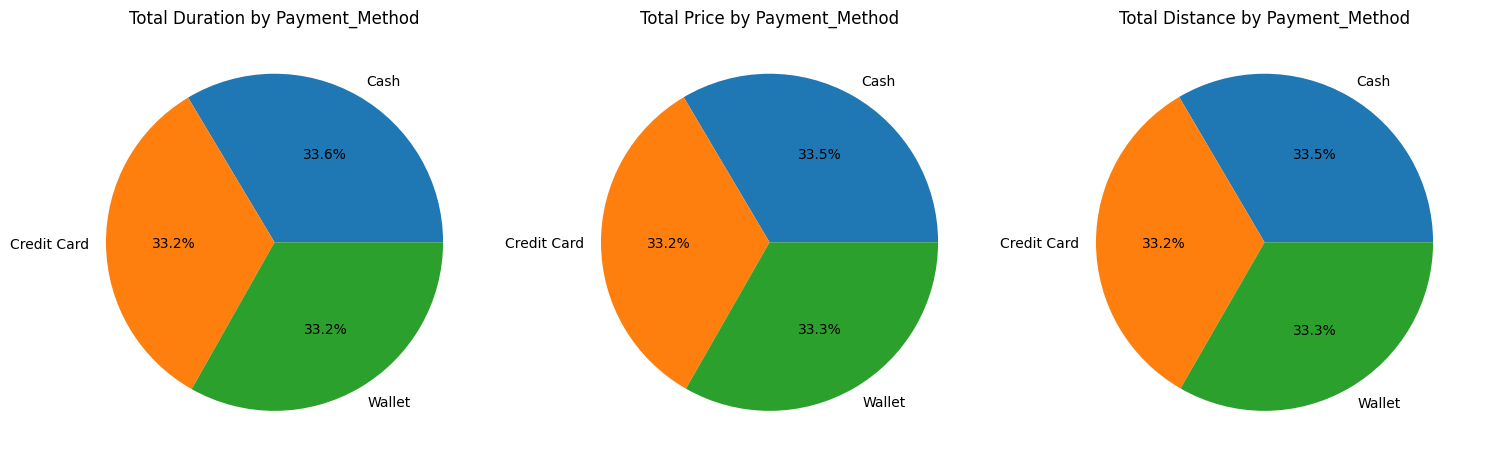

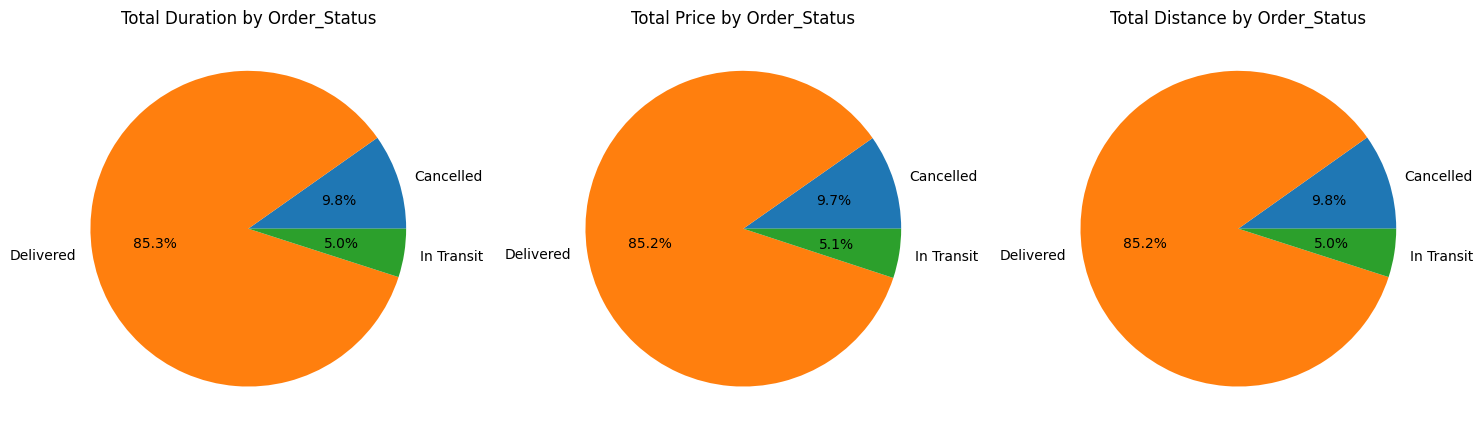

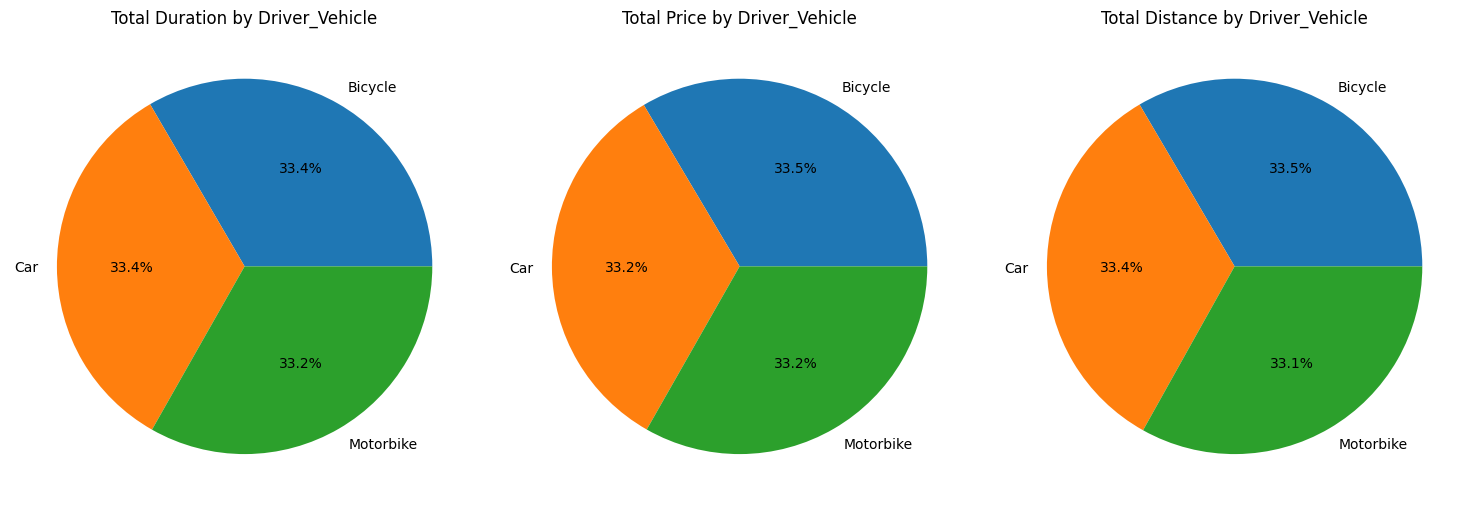

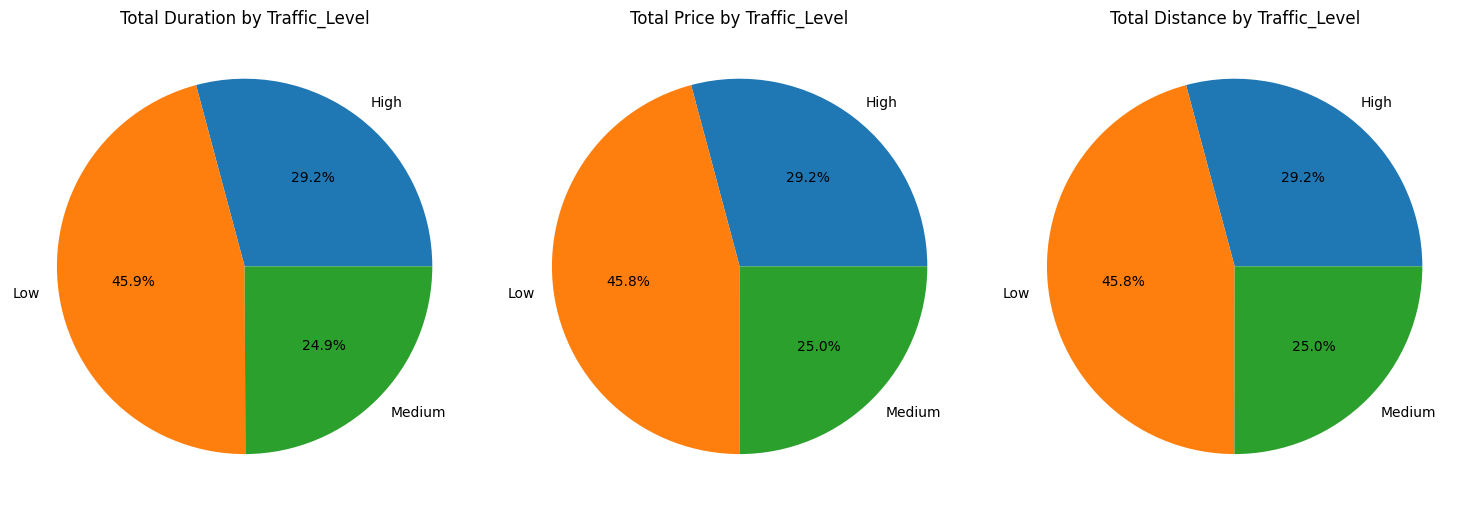

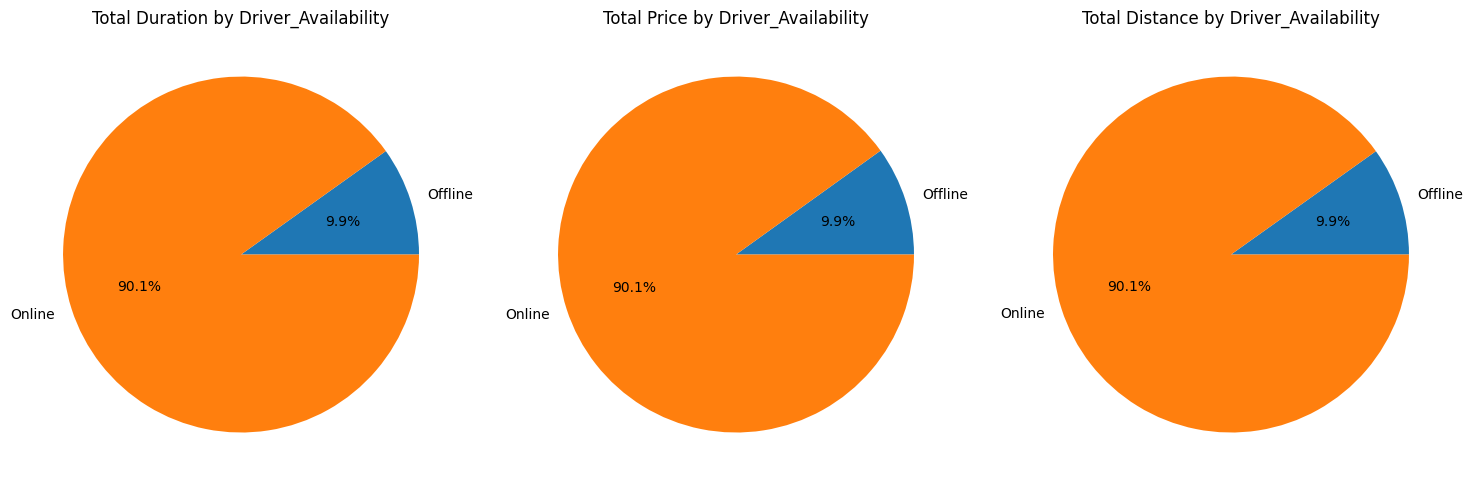

In [14]:
for col in draw_pie_col_list:
    plot_pie(col)

- This dataset is so similar in nature
- No fun 
- So no more EDA
- V1: 24-02-2026 | 08:26 IST

In [26]:
import plotly.express as px
import pandas as pd

# Example data (replace with your actual data)
data = {
    'City': ['New York', 'London', 'Tokyo'],
    'Latitude': [40.7128, 51.5074, 35.6895],
    'Longitude': [-74.0060, -0.1278, 139.6917],
    'Magnitude': [10, 8, 12] # Example data for hover info
}
df = pd.DataFrame(data)

# Create the interactive map
fig = px.scatter_geo(df,
                     lat='Latitude',
                     lon='Longitude',
                     hover_name="City", # Information to display on hover
                     color="Magnitude", # Color points based on magnitude
                     title='Sample Latitude and Longitude Plot')

# Show the figure
fig.show()
